<a href="https://colab.research.google.com/github/nur21horin/machine_learning/blob/main/regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

In [33]:
x,y=make_moons(100,noise=0.25,random_state=2)

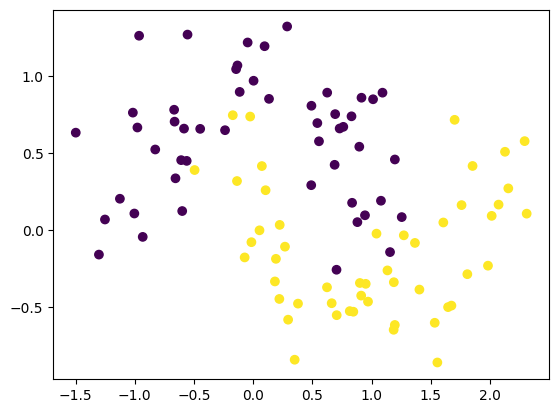

In [34]:
import matplotlib.pyplot as plt
plt.scatter(x[:,0],x[:,1],c=y)
plt.show()

In [35]:
model1=Sequential()
model1.add(Dense(128,input_dim=2,activation='relu'))
model1.add(Dense(128,activation='relu'))
model1.add(Dense(1,activation='sigmoid'))
model1.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
adam=Adam(learning_rate=0.01)
model1.compile(loss='binary_crossentropy',optimizer=adam,metrics=['accuracy'])
history1=model1.fit(x,y,epochs=2000,validation_split=0.2,verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 792us/step


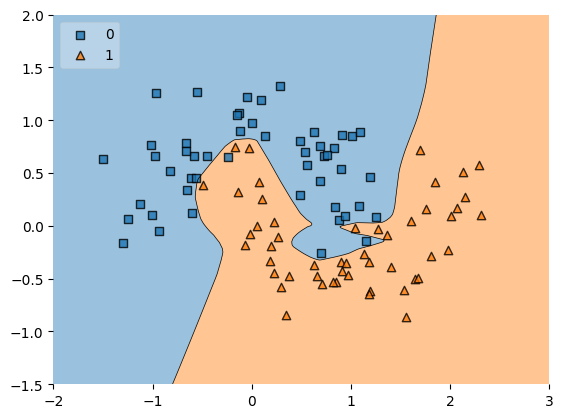

In [37]:
plot_decision_regions(x,y.astype('int'),clf=model1,legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

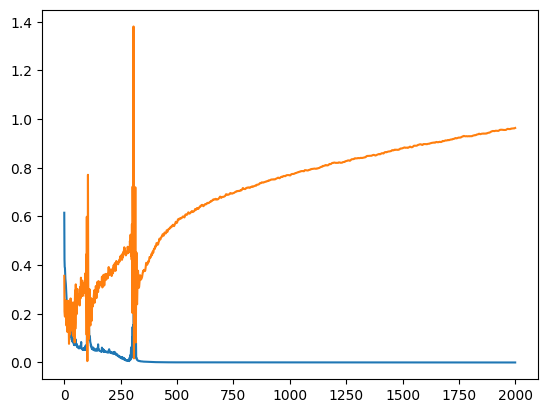

In [38]:
plt.plot(history1.history['loss'],label='loss')
plt.plot(history1.history['val_loss'],label='val_loss')

In [39]:
model2=Sequential()
model2.add(Dense(128,input_dim=2,activation='relu',kernel_regularizer=tensorflow.keras.regularizers.l1(0.001)))
model2.add(Dense(128,activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l1(0.001)))
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
adam=Adam(learning_rate=0.01)
model2.compile(loss='binary_crossentropy',optimizer=adam,metrics=['accuracy'])

history2=model2.fit(x,y,epochs=2000,validation_split=0.2,verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 7s 770us/step


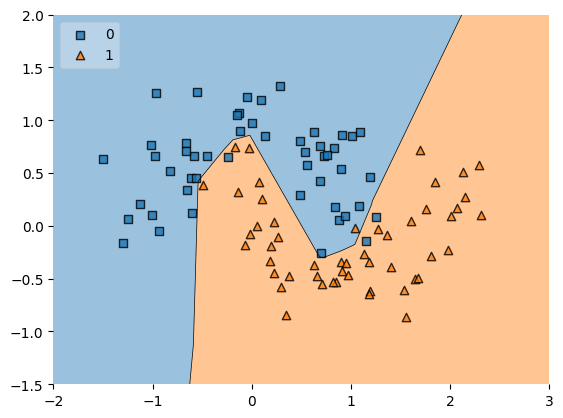

In [41]:
plot_decision_regions(x, y.astype('int'), clf=model2, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

In [42]:
x.shape

(100, 2)

In [43]:
y.shape

(100,)

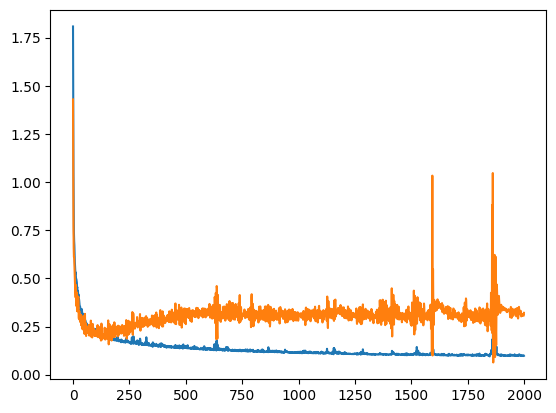

In [44]:
plt.plot(history2.history['loss'],label='loss')
plt.plot(history2.history['val_loss'],label='val_loss')

In [45]:
model1_weight_layer1=model1.get_weights()[0].reshape(256)
model2_weight_layer1=model2.get_weights()[0].reshape(256)

<Axes: >

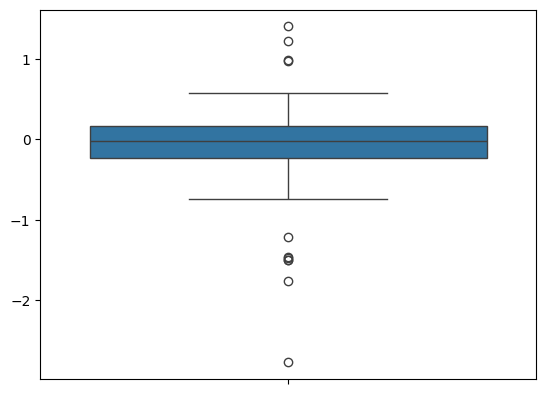

In [46]:
sns.boxplot(model1_weight_layer1)

<Axes: >

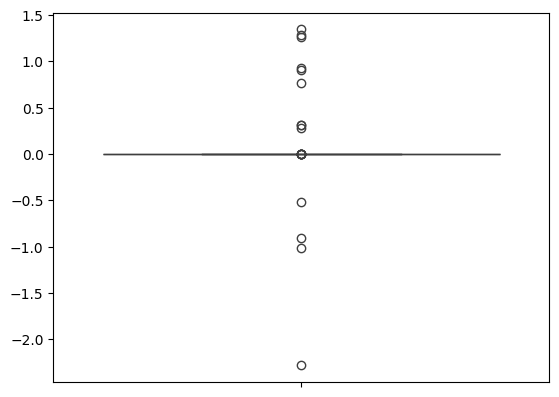

In [47]:
sns.boxplot(model2_weight_layer1)

In [48]:
model1_weight_layer1.min()

np.float32(-2.7732716)

In [49]:
model2_weight_layer1.min()

np.float32(-2.28032)

/tmp/ipykernel_787/2224180084.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model1_weight_layer1)
/tmp/ipykernel_787/2224180084.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model2_weight_layer1)


<Axes: ylabel='Density'>

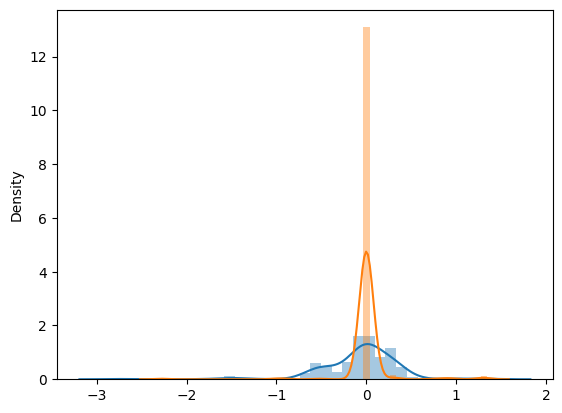

In [50]:
sns.distplot(model1_weight_layer1)
sns.distplot(model2_weight_layer1)

In [51]:
model1.get_weights()[0].reshape(256)

array([-5.27520299e-01, -4.35083181e-01, -4.82588112e-01, -4.19250093e-02,
       -3.79591018e-01, -6.04164489e-02,  3.38002324e-01, -9.33190361e-02,
        3.36053491e-01, -5.71420133e-01, -3.62120084e-02, -4.55486506e-01,
       -5.18320501e-01, -4.76429462e-02,  3.00136954e-01,  2.55283296e-01,
       -5.01245558e-01, -5.92460595e-02, -2.73579776e-01,  2.49460042e-01,
        9.78173465e-02, -5.34073591e-01,  3.36516052e-01,  2.77126849e-01,
       -4.06403452e-01, -2.75377393e-01, -2.70270351e-02,  4.42476779e-01,
        1.80370152e-01,  3.12171370e-01,  3.03785522e-02, -3.13090160e-02,
       -2.31985785e-02, -3.13521117e-01,  2.51505852e-01, -2.91180220e-02,
       -5.12300074e-01, -5.47552943e-01,  1.12534851e-01, -5.63746952e-02,
       -3.34350109e-01,  3.07513446e-01,  7.37877563e-02, -5.12059450e-01,
       -5.49469709e-01,  1.66092679e-01,  1.05718851e-01, -5.24255812e-01,
       -1.64716132e-02, -2.09607691e-01,  2.46805027e-01,  9.28788707e-02,
       -2.20766123e-02, -